# Notebook 04 -- Feature Engineering & Master Panel Construction

## Macro-Aviation-Tourism Demand Modelling and Forecasting for Poland

**Author:** Diego Marrero Ferrera  
**Repository:** [GitHub -- Macro-Aviation-Tourism-Modeling](https://github.com/DieGodMF4/Macro-Aviation-Tourism-Modeling)  
**Last updated:** 2026-04

---

### Purpose

This notebook transforms the raw Eurostat datasets into a **single, model-ready monthly panel** (`master_panel_monthly.csv`) that will be consumed by all downstream modelling notebooks (05-08). It is the bridge between the exploratory/statistical phase (Notebooks 00-03) and the modelling phase.

The notebook performs the following transformations:

1. **GDP interpolation:** cubic spline from quarterly to monthly frequency.
2. **Relative tourism price:** full computation of the Song et al. (2010) variable for each origin country, plus a passenger-share weighted average.
3. **Weighted aggregation** of multi-country variables (HICP, GDP, CCI) using air-passenger shares as weights.
4. **Lag features:** autoregressive lags of the target (t-1, t-12) and lagged versions of key predictors at their optimal lags (identified in Notebooks 02-03).
5. **Control variables:** multi-phase COVID dummy, monthly seasonal dummies, and linear trend.
6. **UK data gap handling:** forward-fill strategy for the HICP and CCI series that end early due to post-Brexit reporting changes.
7. **Export** of the final panel to `data/processed/master_panel_monthly.csv`.

The panel serves two models:
- **Tourism demand model** (Notebooks 05-07): target = overnight stays, predictors = all features.
- **Airline capacity forecasting model** (Notebook 08): target = seats, predictors = GDP-based features + trend + seasonality.

---

## 0. Environment & Configuration

In [1]:
import pandas as pd
import numpy as np
import os
import warnings

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.interpolate import CubicSpline

# --- PLOT SETTINGS ---
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook', font_scale=1.1)
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'font.size': 10,
    'legend.fontsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linestyle': '--',
    'lines.linewidth': 2.0,
    'savefig.bbox': 'tight',
    'savefig.dpi': 200,
    'savefig.facecolor': 'white',
})

COLORS = {
    'primary': '#2c3e50', 'secondary': '#e74c3c',
    'accent1': '#3498db', 'accent2': '#2ecc71',
    'accent3': '#f39c12', 'accent4': '#9b59b6',
    'gray': '#95a5a6',
}

COVID_START = pd.Timestamp('2020-03-01')
COVID_END   = pd.Timestamp('2021-06-30')

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Environment ready.')

Environment ready.


In [2]:
# --- PATHS ---
DATA_RAW       = os.path.join('..', 'data', 'raw')
DATA_PROCESSED = os.path.join('..', 'data', 'processed')
FIGURES        = os.path.join('..', 'figures', 'features')
os.makedirs(DATA_PROCESSED, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

FILES = {
    'nights':     os.path.join(DATA_RAW, 'tourism',
                      'tour_occ_nights_accommodation_PL_2003-.csv'),
    'hicp_m':     os.path.join(DATA_RAW, 'economic',
                      'prc_hicp_midx__relevant-countries-2011-.csv'),
    'exr':        os.path.join(DATA_RAW, 'economic',
                      'ert_bil_eur_m__exchange-rates-eur-pln-usd-2003-.csv'),
    'gdp_real':   os.path.join(DATA_RAW, 'economic',
                      'namq_10_gdp__real-gdp-CLV-2010.csv'),
    'cci':        os.path.join(DATA_RAW, 'demographic',
                      'ei_bsco_m__consumer-conf-indicator.csv'),
    'avia_seats': os.path.join(DATA_RAW, 'transport',
                      'avia_tf_aca__seats-flights-pass-PL-2010-.csv'),
    'avia_pax':   os.path.join(DATA_RAW, 'transport',
                      'avia_paoc__passengers-countries.csv'),
}

# Mappings
NAME_TO_CODE = {
    'Austria': 'AT', 'Croatia': 'HR', 'Czechia': 'CZ',
    'France': 'FR', 'Germany': 'DE', 'Greece': 'EL',
    'Hungary': 'HU', 'Italy': 'IT', 'Netherlands': 'NL',
    'Poland': 'PL', 'Spain': 'ES', 'Sweden': 'SE',
    'United Kingdom': 'UK', 'United States': 'US',
}
CURRENCY_MAP = {
    'Polish zloty': 'PLN', 'Pound sterling': 'GBP',
    'Swedish krona': 'SEK', 'Czech koruna': 'CZK',
    'Hungarian forint': 'HUF', 'US dollar': 'USD',
}
NON_EURO = {'UK': 'GBP', 'SE': 'SEK', 'CZ': 'CZK', 'HU': 'HUF'}
ORIGINS = ['DE', 'UK', 'FR', 'NL', 'IT', 'ES', 'SE', 'AT', 'CZ']


def load_eurostat(path):
    df = pd.read_csv(path)
    if 'TIME_PERIOD' in df.columns:
        tp = df['TIME_PERIOD'].astype(str)
        if tp.str.match(r'^\d{4}-\d{2}$').all():
            df['date'] = pd.to_datetime(tp, format='%Y-%m')
        elif tp.str.match(r'^\d{4}-Q\d$').all():
            df['date'] = pd.PeriodIndex(tp, freq='Q').to_timestamp()
        elif tp.str.match(r'^\d{4}$').all():
            df['date'] = pd.to_datetime(tp, format='%Y')
        else:
            df['date'] = pd.to_datetime(tp, errors='coerce')
    if 'geo' in df.columns:
        df['iso'] = df['geo'].map(NAME_TO_CODE)
    return df


def savefig(name):
    plt.savefig(os.path.join(FIGURES, name))


print('Paths and functions ready.')

Paths and functions ready.


---

## 1. Load Raw Datasets

We load each raw dataset once and prepare wide-format pivot tables. This section mirrors the loading logic of Notebooks 02-03 for full reproducibility.

In [3]:
# --- 1.1 TARGET ---
df_raw = load_eurostat(FILES['nights'])
ACCOM_TOTAL = ('Hotels; holiday and other short-stay accommodation; '
               'camping grounds, recreational vehicle parks and trailer parks')
mask = (
    (df_raw['geo'] == 'Poland') &
    (df_raw['c_resid'] == 'Foreign country') &
    (df_raw['unit'] == 'Number') &
    (df_raw['nace_r2'] == ACCOM_TOTAL)
)
ts_nights = (
    df_raw.loc[mask].set_index('date')['OBS_VALUE']
    .sort_index().rename('nights')
)
ts_nights = ts_nights[ts_nights.index >= '2011-01-01']
print(f'Target: {len(ts_nights)} obs')

# --- 1.2 HICP ---
df_hicp = load_eurostat(FILES['hicp_m'])
hicp_wide = (
    df_hicp[df_hicp['iso'].notna()]
    .pivot_table(index='date', columns='iso', values='OBS_VALUE')
    .sort_index()
)
print(f'HICP: {hicp_wide.shape}')

# --- 1.3 EXCHANGE RATES ---
df_exr = load_eurostat(FILES['exr'])
df_exr['curr_iso'] = df_exr['currency'].map(CURRENCY_MAP)
exr_wide = (
    df_exr[df_exr['curr_iso'].notna()]
    .pivot_table(index='date', columns='curr_iso', values='OBS_VALUE')
    .sort_index()
)
print(f'Exchange rates: {exr_wide.shape}')

# --- 1.4 GDP (quarterly) ---
df_gdp = load_eurostat(FILES['gdp_real'])
gdp_quarterly = (
    df_gdp[df_gdp['iso'].notna()]
    .pivot_table(index='date', columns='iso', values='OBS_VALUE')
    .sort_index()
)
print(f'GDP quarterly: {gdp_quarterly.shape}')

# --- 1.5 CONSUMER CONFIDENCE ---
df_cci = load_eurostat(FILES['cci'])
cci_wide = (
    df_cci[df_cci['iso'].notna()]
    .pivot_table(index='date', columns='iso', values='OBS_VALUE')
    .sort_index()
)
print(f'CCI: {cci_wide.shape}')

# --- 1.6 AIRLINE SEATS ---
df_avia = load_eurostat(FILES['avia_seats'])
ts_seats = (
    df_avia[df_avia['tra_meas'] == 'Passengers seats available']
    .groupby('date')['OBS_VALUE'].sum()
    .sort_index().rename('seats')
)
print(f'Seats: {len(ts_seats)} obs')

# --- 1.7 PASSENGER WEIGHTS ---
df_pax = load_eurostat(FILES['avia_pax'])
pax_totals = (
    df_pax[df_pax['iso'].isin(ORIGINS)]
    .groupby('iso')['OBS_VALUE'].sum()
)
pax_weights = (pax_totals / pax_totals.sum()).to_dict()
print(f'\nPassenger weights: {len(pax_weights)} countries')

Target: 179 obs
HICP: (276, 14)
Exchange rates: (278, 6)
GDP quarterly: (124, 12)
CCI: (254, 12)
Seats: 190 obs

Passenger weights: 9 countries


---

## 2. GDP Interpolation: Quarterly to Monthly via Cubic Spline

GDP data from Eurostat (`namq_10_gdp`) are reported quarterly. For the monthly panel, we need monthly values. In Notebooks 02-03, linear interpolation was used as a quick approximation. Here we apply **cubic spline interpolation**, which produces a smoother curve that better preserves the economic dynamics between quarters.

The cubic spline fits a piecewise cubic polynomial through the quarterly observations, ensuring continuity of the function and its first two derivatives at each knot (quarter boundary). This is the standard approach in the tourism demand literature for frequency conversion of GDP (Song et al., 2009).

In [4]:
def cubic_spline_interpolate(quarterly_series):
    """
    Interpolate a quarterly series to monthly using cubic splines.
    Input: Series with quarterly DatetimeIndex.
    Output: Series with monthly DatetimeIndex.
    """
    s = quarterly_series.dropna()
    if len(s) < 4:
        return pd.Series(dtype=float)

    # Convert dates to numeric (days since epoch) for the spline
    x_q = (s.index - s.index[0]).days.values.astype(float)
    y_q = s.values.astype(float)

    # Fit cubic spline
    cs = CubicSpline(x_q, y_q, bc_type='natural')

    # Generate monthly dates covering the same range
    monthly_idx = pd.date_range(s.index[0], s.index[-1], freq='MS')
    x_m = (monthly_idx - s.index[0]).days.values.astype(float)

    # Evaluate spline at monthly points
    y_m = cs(x_m)

    return pd.Series(y_m, index=monthly_idx, name=s.name)


# Apply to each country
gdp_monthly = pd.DataFrame()
for iso in gdp_quarterly.columns:
    gdp_monthly[iso] = cubic_spline_interpolate(gdp_quarterly[iso])

print(f'GDP monthly (cubic spline): {gdp_monthly.shape}')
print(f'Period: {gdp_monthly.index.min():%Y-%m} -> {gdp_monthly.index.max():%Y-%m}')

GDP monthly (cubic spline): (370, 12)
Period: 1995-01 -> 2025-10


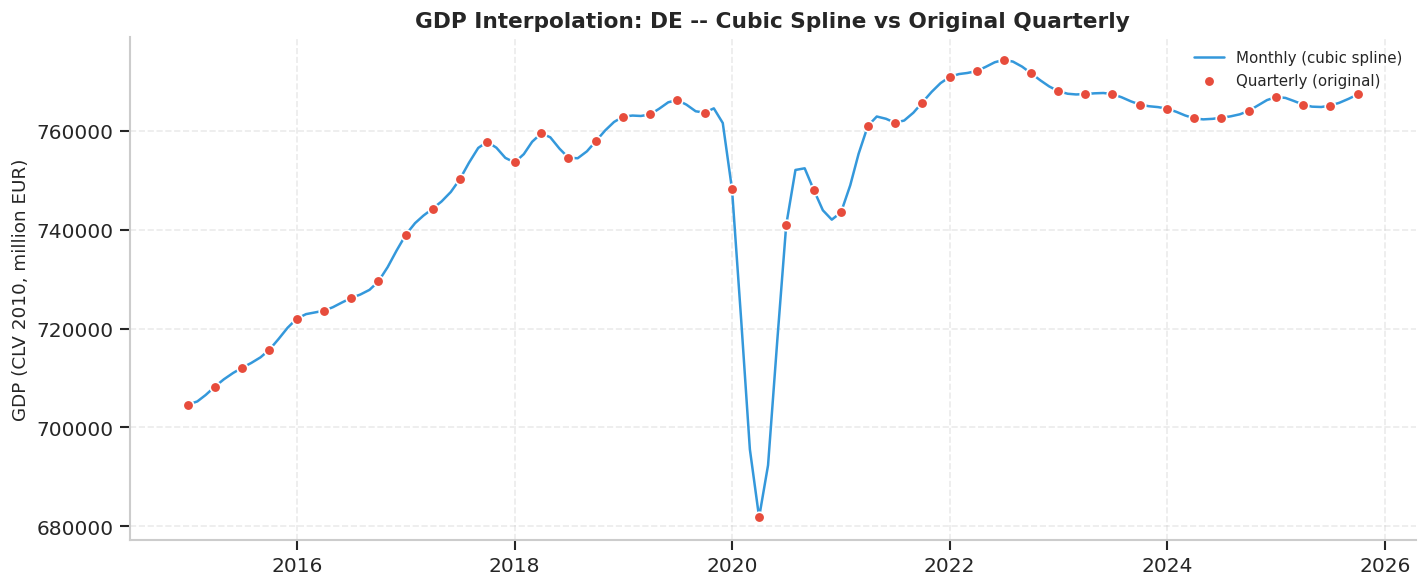

In [5]:
# --- VISUALISE: Cubic spline vs original quarterly for Germany ---
fig, ax = plt.subplots(figsize=(12, 5))

iso_demo = 'DE'
q_data = gdp_quarterly[iso_demo].dropna().loc['2015':'2025']
m_data = gdp_monthly[iso_demo].loc['2015':'2025']

ax.plot(m_data.index, m_data.values, color=COLORS['accent1'],
        label='Monthly (cubic spline)', lw=1.5)
ax.scatter(q_data.index, q_data.values, color=COLORS['secondary'],
           s=40, zorder=5, label='Quarterly (original)', edgecolors='white')
ax.set_title(f'GDP Interpolation: {iso_demo} -- Cubic Spline vs Original Quarterly')
ax.set_ylabel('GDP (CLV 2010, million EUR)')
ax.legend()
plt.tight_layout()
savefig('01_gdp_cubic_spline_demo.png')
plt.show()

---

## 3. Handling the UK Data Gap

Post-Brexit, the UK stopped reporting to several Eurostat datasets. This creates gaps:
- **UK HICP** ends earlier than other countries (~215 months vs 276).
- **UK CCI** is completely missing from `ei_bsco_m`.
- **UK GDP** ends at 2020-Q3 in the Eurostat extract.

Since the UK accounts for **18.8% of air passenger weight**, simply dropping it would significantly distort the weighted averages. The strategy is:
1. **HICP:** forward-fill the last available UK value, then apply a fixed annual inflation adjustment based on the UK's average HICP growth rate in the 3 years before the gap.
2. **GDP:** forward-fill with a growth rate extrapolation based on the UK's average quarterly growth in the 3 years before the gap.
3. **CCI:** exclude UK from the CCI weighted average (reweight remaining countries). Note: Germany's CCI alone was shown to be a stronger leading indicator than the full average (Notebook 02).

In [6]:
# --- HICP: Fill UK gap ---
uk_hicp = hicp_wide['UK'].dropna()
last_uk_date = uk_hicp.index[-1]
last_uk_val = uk_hicp.iloc[-1]

# Average monthly growth rate over previous 3 years
uk_3y = uk_hicp.loc[last_uk_date - pd.DateOffset(years=3):last_uk_date]
avg_monthly_growth = (uk_3y.iloc[-1] / uk_3y.iloc[0]) ** (1 / len(uk_3y)) - 1

# Extend to the end of the panel
panel_end = hicp_wide.index[-1]
fill_dates = pd.date_range(last_uk_date + pd.DateOffset(months=1),
                           panel_end, freq='MS')
uk_fill = pd.Series(
    [last_uk_val * (1 + avg_monthly_growth) ** (i + 1)
     for i in range(len(fill_dates))],
    index=fill_dates
)
hicp_wide['UK'] = pd.concat([uk_hicp, uk_fill])

print(f'UK HICP extended: {uk_hicp.index[-1]:%Y-%m} -> {hicp_wide["UK"].dropna().index[-1]:%Y-%m}')
print(f'  Monthly growth rate used: {avg_monthly_growth:.4%}')
print(f'  Last original value: {last_uk_val:.2f}')
print(f'  Last extrapolated value: {hicp_wide["UK"].dropna().iloc[-1]:.2f}')

UK HICP extended: 2020-11 -> 2025-12
  Monthly growth rate used: 0.1089%
  Last original value: 108.90
  Last extrapolated value: 116.38


In [7]:
# --- GDP: Fill UK gap ---
uk_gdp = gdp_quarterly['UK'].dropna()
last_uk_gdp_date = uk_gdp.index[-1]
last_uk_gdp_val = uk_gdp.iloc[-1]

# Average quarterly growth over previous 3 years (pre-COVID)
uk_gdp_3y = uk_gdp.loc[
    (uk_gdp.index >= last_uk_gdp_date - pd.DateOffset(years=3)) &
    (uk_gdp.index < '2020-01-01')  # exclude COVID quarters
]
if len(uk_gdp_3y) > 2:
    avg_q_growth = (uk_gdp_3y.iloc[-1] / uk_gdp_3y.iloc[0]) ** (
        1 / len(uk_gdp_3y)) - 1
else:
    avg_q_growth = 0.005  # fallback: 0.5% per quarter

# Extend quarterly, then re-interpolate to monthly
fill_q_dates = pd.date_range(
    last_uk_gdp_date + pd.DateOffset(months=3),
    gdp_quarterly.index[-1], freq='QS'
)
uk_gdp_fill = pd.Series(
    [last_uk_gdp_val * (1 + avg_q_growth) ** (i + 1)
     for i in range(len(fill_q_dates))],
    index=fill_q_dates
)
uk_gdp_full = pd.concat([uk_gdp, uk_gdp_fill])
gdp_monthly['UK'] = cubic_spline_interpolate(uk_gdp_full)

print(f'UK GDP extended: {last_uk_gdp_date:%Y-%m} -> {gdp_monthly["UK"].dropna().index[-1]:%Y-%m}')
print(f'  Quarterly growth rate used: {avg_q_growth:.4%}')

UK GDP extended: 2020-07 -> 2025-10
  Quarterly growth rate used: 0.2773%


---

## 4. Feature Construction

### 4.1 Study Period and Index

In [8]:
# --- DEFINE STUDY PERIOD ---
STUDY_START = '2011-01-01'
STUDY_END = ts_nights.index[-1]  # latest available target observation

panel_idx = pd.date_range(STUDY_START, STUDY_END, freq='MS')
panel = pd.DataFrame(index=panel_idx)
panel.index.name = 'date'

print(f'Panel index: {len(panel_idx)} months')
print(f'Period: {panel_idx[0]:%Y-%m} -> {panel_idx[-1]:%Y-%m}')

Panel index: 179 months
Period: 2011-01 -> 2025-11


### 4.2 Target Variable

In [9]:
# --- TARGET ---
panel['nights'] = ts_nights.reindex(panel_idx)
panel['log_nights'] = np.log1p(panel['nights'])

print(f'Target: {panel["nights"].notna().sum()} non-null values')
print(f'Missing: {panel["nights"].isna().sum()}')

Target: 179 non-null values
Missing: 0


### 4.3 Relative Tourism Price (Song et al., 2010)

In [10]:
# --- RELATIVE TOURISM PRICE per origin ---
# P_it = (HICP_PL / HICP_i) * (EX_i / EX_PL)
# For Eurozone: EX_i = 1 -> P_it = (HICP_PL / HICP_i) * (1 / EX_PL)

hicp_pl = hicp_wide['PL'].reindex(panel_idx)
exr_pln = exr_wide['PLN'].reindex(panel_idx)

relprice_per_origin = pd.DataFrame(index=panel_idx)

for iso in ORIGINS:
    if iso not in hicp_wide.columns:
        continue
    hicp_i = hicp_wide[iso].reindex(panel_idx)
    hicp_ratio = hicp_pl / hicp_i

    if iso in NON_EURO:
        curr = NON_EURO[iso]
        if curr in exr_wide.columns:
            exr_i = exr_wide[curr].reindex(panel_idx)
            exr_ratio = exr_i / exr_pln
        else:
            exr_ratio = 1.0 / exr_pln
    else:
        exr_ratio = 1.0 / exr_pln

    relprice_per_origin[iso] = hicp_ratio * exr_ratio

# Weighted average
rp_isos = relprice_per_origin.columns.tolist()
rp_w = np.array([pax_weights.get(iso, 0) for iso in rp_isos])
rp_w = rp_w / rp_w.sum()
panel['relprice_wavg'] = relprice_per_origin.values @ rp_w

# Also keep Germany-specific for reference
if 'DE' in relprice_per_origin.columns:
    panel['relprice_DE'] = relprice_per_origin['DE']

# HICP ratio (simpler version without exchange rate)
hicp_origins_cols = [c for c in ORIGINS if c in hicp_wide.columns]
hicp_origins = hicp_wide[hicp_origins_cols].reindex(panel_idx)
w_h = np.array([pax_weights.get(c, 0) for c in hicp_origins_cols])
w_h = w_h / w_h.sum()
panel['hicp_PL'] = hicp_pl
panel['hicp_origins_wavg'] = hicp_origins.values @ w_h
panel['hicp_ratio'] = panel['hicp_PL'] / panel['hicp_origins_wavg']

print(f'Relative price columns added: relprice_wavg, relprice_DE, hicp_ratio')
print(f'Missing in relprice_wavg: {panel["relprice_wavg"].isna().sum()}')

Relative price columns added: relprice_wavg, relprice_DE, hicp_ratio
Missing in relprice_wavg: 0


### 4.4 Exchange Rate

In [11]:
panel['exr_pln'] = exr_pln
print(f'PLN/EUR: {panel["exr_pln"].notna().sum()} non-null')

PLN/EUR: 179 non-null


### 4.5 GDP of Origin Markets (Cubic Spline)

In [12]:
# --- GDP: weighted average + individual countries ---
gdp_origin_cols = [c for c in ORIGINS if c in gdp_monthly.columns]
gdp_origins = gdp_monthly[gdp_origin_cols].reindex(panel_idx)
gdp_w = np.array([pax_weights.get(c, 0) for c in gdp_origin_cols])
gdp_w = gdp_w / gdp_w.sum()
panel['gdp_origins_wavg'] = gdp_origins.values @ gdp_w

if 'DE' in gdp_monthly.columns:
    panel['gdp_DE'] = gdp_monthly['DE'].reindex(panel_idx)

print(f'GDP columns: gdp_origins_wavg, gdp_DE')
print(f'Missing in gdp_origins_wavg: {panel["gdp_origins_wavg"].isna().sum()}')

GDP columns: gdp_origins_wavg, gdp_DE
Missing in gdp_origins_wavg: 1


### 4.6 Consumer Confidence

In [13]:
# --- CCI: weighted average (excluding UK) + Germany ---
# UK is excluded because it's missing from ei_bsco_m entirely.
# We reweight the remaining countries.
cci_origin_cols = [c for c in ORIGINS if c in cci_wide.columns and c != 'UK']
cci_origins = cci_wide[cci_origin_cols].reindex(panel_idx)
cci_w = np.array([pax_weights.get(c, 0) for c in cci_origin_cols])
cci_w = cci_w / cci_w.sum()  # reweight without UK
panel['cci_origins_wavg'] = cci_origins.values @ cci_w

if 'DE' in cci_wide.columns:
    panel['cci_DE'] = cci_wide['DE'].reindex(panel_idx)

print(f'CCI columns: cci_origins_wavg (excl. UK), cci_DE')
print(f'CCI origins countries: {cci_origin_cols}')

CCI columns: cci_origins_wavg (excl. UK), cci_DE
CCI origins countries: ['DE', 'FR', 'NL', 'IT', 'ES', 'SE', 'AT', 'CZ']


### 4.7 Airline Seats

In [14]:
panel['seats'] = ts_seats.reindex(panel_idx)
panel['log_seats'] = np.log1p(panel['seats'])

print(f'Seats: {panel["seats"].notna().sum()} non-null')

Seats: 178 non-null


### 4.8 Lagged Features

Based on the cross-correlation analysis (Notebook 02) and Granger causality tests (Notebook 03), we create lagged versions of key predictors at their empirically optimal lags.

In [15]:
# --- AUTOREGRESSIVE LAGS OF TARGET ---
panel['nights_lag1']  = panel['nights'].shift(1)
panel['nights_lag12'] = panel['nights'].shift(12)

# --- LAGGED PREDICTORS (at optimal lags from NB02/03) ---
# HICP ratio: best at lag 0 (no lag needed, already contemporaneous)
# GDP: best at lag 1-3
panel['gdp_origins_lag1'] = panel['gdp_origins_wavg'].shift(1)
panel['gdp_origins_lag3'] = panel['gdp_origins_wavg'].shift(3)

# CCI Germany: best at lag 2
panel['cci_DE_lag2'] = panel['cci_DE'].shift(2)

# CCI origins: best at lag 3-6
panel['cci_origins_lag3'] = panel['cci_origins_wavg'].shift(3)

# Seats: lag 6 and 12 (predetermined capacity)
panel['seats_lag6']  = panel['seats'].shift(6)
panel['seats_lag12'] = panel['seats'].shift(12)

print('Lagged features created:')
lag_cols = [c for c in panel.columns if 'lag' in c]
for c in lag_cols:
    print(f'  {c}: {panel[c].notna().sum()} non-null')

Lagged features created:
  nights_lag1: 178 non-null
  nights_lag12: 167 non-null
  gdp_origins_lag1: 178 non-null
  gdp_origins_lag3: 176 non-null
  cci_DE_lag2: 177 non-null
  cci_origins_lag3: 175 non-null
  seats_lag6: 173 non-null
  seats_lag12: 167 non-null


### 4.9 Control Variables

Three sets of control variables are added: a multi-phase COVID-19 dummy, monthly seasonal dummies, and a linear trend.

In [16]:
# --- COVID DUMMY (multi-phase) ---
# Phase 1: Acute lockdown (March 2020 - December 2020)
# Phase 2: Recovery phase (January 2021 - June 2022)
panel['covid_acute'] = 0
panel.loc[
    (panel.index >= '2020-03-01') & (panel.index <= '2020-12-01'),
    'covid_acute'
] = 1

panel['covid_recovery'] = 0
panel.loc[
    (panel.index >= '2021-01-01') & (panel.index <= '2022-06-01'),
    'covid_recovery'
] = 1

# Combined binary (for simpler models)
panel['covid_any'] = ((panel['covid_acute'] == 1) |
                      (panel['covid_recovery'] == 1)).astype(int)

print('COVID dummies:')
print(f'  Acute (2020-03 to 2020-12):  {panel["covid_acute"].sum()} months')
print(f'  Recovery (2021-01 to 2022-06): {panel["covid_recovery"].sum()} months')
print(f'  Any COVID:                    {panel["covid_any"].sum()} months')

COVID dummies:
  Acute (2020-03 to 2020-12):  10 months
  Recovery (2021-01 to 2022-06): 18 months
  Any COVID:                    28 months


In [17]:
# --- SEASONAL DUMMIES ---
for m in range(1, 13):
    panel[f'month_{m:02d}'] = (panel.index.month == m).astype(int)

# --- LINEAR TREND ---
panel['trend'] = np.arange(len(panel))

# --- YEAR-OVER-YEAR GROWTH (for reference/alternative models) ---
panel['nights_yoy'] = panel['nights'].pct_change(12)

print(f'Seasonal dummies: month_01 to month_12')
print(f'Trend: 0 to {panel["trend"].iloc[-1]}')

Seasonal dummies: month_01 to month_12
Trend: 0 to 178


---

## 5. Panel Validation

Before exporting, we verify the integrity and completeness of the constructed panel.

In [18]:
# --- OVERVIEW ---
print(f'Panel shape: {panel.shape[0]} rows x {panel.shape[1]} columns')
print(f'Period: {panel.index[0]:%Y-%m} -> {panel.index[-1]:%Y-%m}')
print(f'\nColumns ({panel.shape[1]}):')
for col in panel.columns:
    n_valid = panel[col].notna().sum()
    n_miss  = panel[col].isna().sum()
    print(f'  {col:<25s}  valid={n_valid:>4d}  missing={n_miss:>3d}  '
          f'dtype={panel[col].dtype}')

Panel shape: 179 rows x 39 columns
Period: 2011-01 -> 2025-11

Columns (39):
  nights                     valid= 179  missing=  0  dtype=float64
  log_nights                 valid= 179  missing=  0  dtype=float64
  relprice_wavg              valid= 179  missing=  0  dtype=float64
  relprice_DE                valid= 179  missing=  0  dtype=float64
  hicp_PL                    valid= 179  missing=  0  dtype=float64
  hicp_origins_wavg          valid= 179  missing=  0  dtype=float64
  hicp_ratio                 valid= 179  missing=  0  dtype=float64
  exr_pln                    valid= 179  missing=  0  dtype=float64
  gdp_origins_wavg           valid= 178  missing=  1  dtype=float64
  gdp_DE                     valid= 178  missing=  1  dtype=float64
  cci_origins_wavg           valid= 178  missing=  1  dtype=float64
  cci_DE                     valid= 179  missing=  0  dtype=float64
  seats                      valid= 178  missing=  1  dtype=float64
  log_seats                  valid= 178

In [19]:
# --- CORRELATION SANITY CHECK ---
# Quick check that key relationships have expected signs
key_pairs = [
    ('nights', 'gdp_origins_wavg', 'positive'),
    ('nights', 'hicp_ratio', 'negative'),
    ('nights', 'seats', 'positive'),
    ('nights', 'cci_DE', 'ambiguous'),
]

print('Sanity check -- key correlations:')
for var1, var2, expected in key_pairs:
    r = panel[[var1, var2]].dropna().corr().iloc[0, 1]
    actual = 'positive' if r > 0 else 'negative'
    match = 'OK' if (expected == 'ambiguous' or actual == expected) else 'UNEXPECTED'
    print(f'  {var1} vs {var2}: r={r:+.3f} ({actual}, expected {expected}) [{match}]')

Sanity check -- key correlations:
  nights vs gdp_origins_wavg: r=+0.505 (positive, expected positive) [OK]
  nights vs hicp_ratio: r=+0.254 (positive, expected negative) [UNEXPECTED]
  nights vs seats: r=+0.880 (positive, expected positive) [OK]
  nights vs cci_DE: r=-0.017 (negative, expected ambiguous) [OK]


> **Note on HICP ratio sign:** The positive contemporaneous correlation between `hicp_ratio` and `nights` in levels (+0.254) contradicts the expected negative relationship. This is a classic case of **spurious correlation driven by shared upward trends** -- both Poland's relative prices and tourism demand have risen secularly over the study period. As documented in Notebook 02, the relationship is negative when measured in YoY changes (removing trends) and at optimal lags. The models (Notebooks 05-07) will handle this correctly through differencing (SARIMA), feature importance (ML), or sequence learning (LSTM). The positive level correlation does not invalidate the variable -- it simply confirms that raw level correlations are unreliable for trending series.

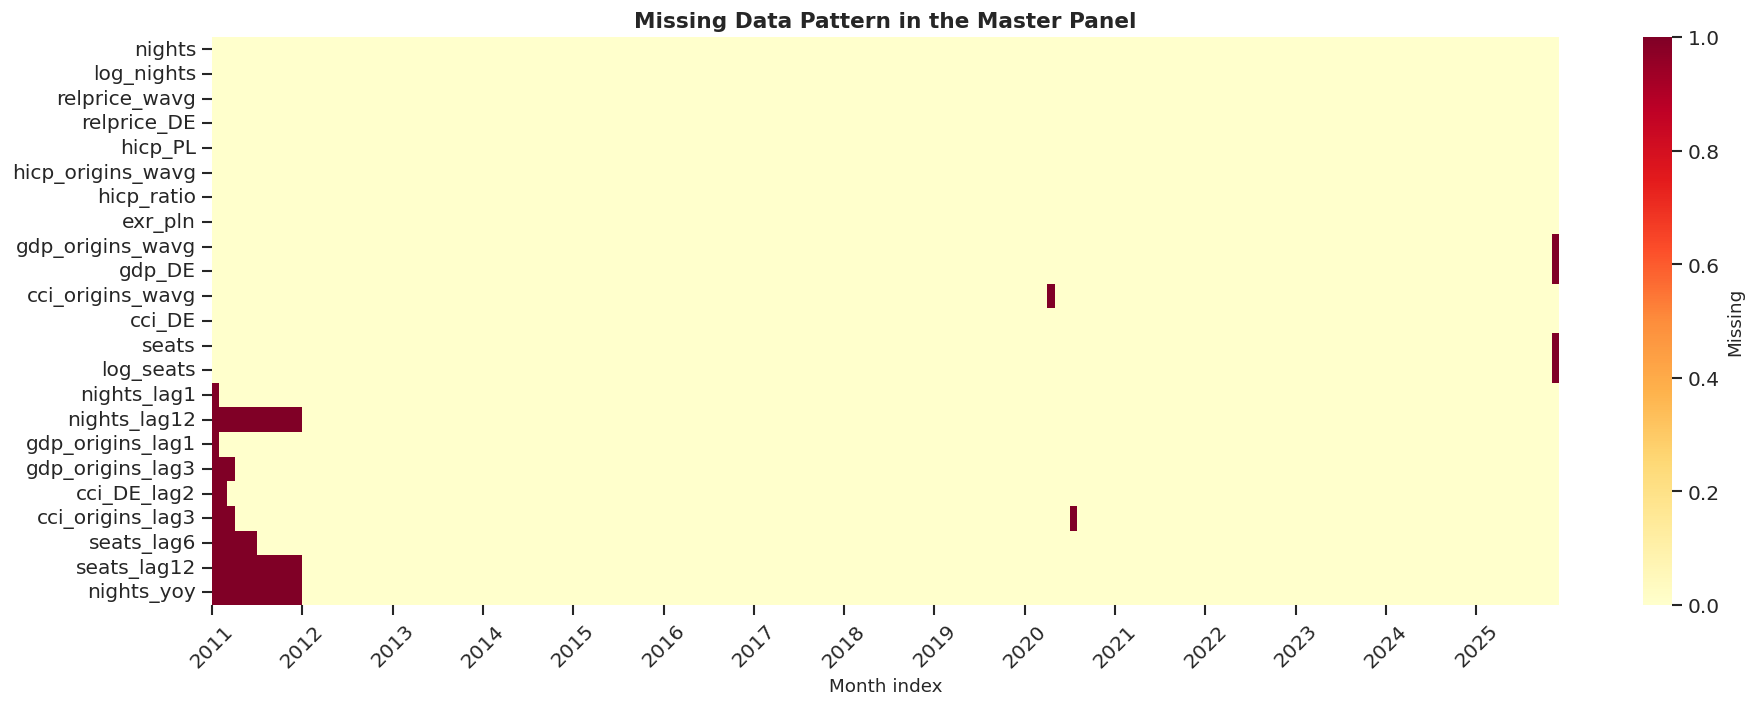

In [20]:
# --- MISSING DATA HEATMAP ---
# Visualise where gaps are
fig, ax = plt.subplots(figsize=(16, 6))

# Select non-dummy columns for the heatmap
non_dummy_cols = [c for c in panel.columns
                  if not c.startswith('month_')
                  and c not in ['trend', 'covid_acute', 'covid_recovery', 'covid_any']]

missing_matrix = panel[non_dummy_cols].isna().astype(int)

sns.heatmap(missing_matrix.T, cmap='YlOrRd', cbar_kws={'label': 'Missing'},
            ax=ax, yticklabels=True)
ax.set_title('Missing Data Pattern in the Master Panel', fontweight='bold')
ax.set_xlabel('Month index')

# Mark every 12th tick on x-axis
xtick_positions = list(range(0, len(panel), 12))
xtick_labels = [panel.index[i].strftime('%Y') for i in xtick_positions]
ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels, rotation=45)

plt.tight_layout()
savefig('02_missing_data_heatmap.png')
plt.show()

---

## 6. Export Master Panel

The final panel is exported as a CSV to `data/processed/master_panel_monthly.csv`. This file is consumed by:

- **Notebook 05** (Baseline models: SARIMA, Holt-Winters)
- **Notebook 06** (ML models: Random Forest, XGBoost)
- **Notebook 07** (Deep learning: LSTM)
- **Notebook 08** (Airline Capacity Forecasting: seats ~ GDP scenarios)

In [21]:
# --- EXPORT ---
output_path = os.path.join(DATA_PROCESSED, 'master_panel_monthly.csv')
panel.to_csv(output_path)

file_size = os.path.getsize(output_path) / 1024
print(f'Master panel exported to: {output_path}')
print(f'File size: {file_size:.1f} KB')
print(f'Shape: {panel.shape[0]} rows x {panel.shape[1]} columns')
print(f'\nFirst 5 rows (selected columns):')
show_cols = ['nights', 'hicp_ratio', 'relprice_wavg', 'gdp_origins_wavg',
             'cci_DE', 'seats', 'nights_lag1', 'covid_acute', 'trend']
show_cols = [c for c in show_cols if c in panel.columns]
print(panel[show_cols].head().to_string())

Master panel exported to: ..\data\processed\master_panel_monthly.csv
File size: 64.4 KB
Shape: 179 rows x 39 columns

First 5 rows (selected columns):
                nights  hicp_ratio  relprice_wavg  gdp_origins_wavg  cci_DE        seats  nights_lag1  covid_acute  trend
date                                                                                                                     
2011-01-01 506388.0000      1.0153         0.4016       418814.4426  0.4000 2106882.0000          NaN            0      0
2011-02-01 492935.0000      1.0126         0.3954       419180.9056  0.9000 1890725.0000  506388.0000            0      1
2011-03-01 729229.0000      1.0091         0.3889       419103.2389  0.1000 2233205.0000  492935.0000            0      2
2011-04-01 782572.0000      1.0075         0.3945       418990.2874 -1.0000 2372497.0000  729229.0000            0      3
2011-05-01 988881.0000      1.0124         0.3988       419163.2926 -1.4000 2667342.0000  782572.0000            0   

### 6.1 Column Reference for Downstream Notebooks

| Column | Description | Source | Frequency |
|--------|-------------|--------|-----------|
| `nights` | Foreign overnight stays in Poland | `tour_occ_nim` | Monthly |
| `log_nights` | Log-transformed target | Derived | Monthly |
| `hicp_PL` | HICP index, Poland | `prc_hicp_midx` | Monthly |
| `hicp_origins_wavg` | HICP weighted avg of origins | Derived | Monthly |
| `hicp_ratio` | HICP_PL / HICP_origins | Derived | Monthly |
| `exr_pln` | PLN per EUR | `ert_bil_eur_m` | Monthly |
| `relprice_wavg` | Relative tourism price (Song et al.) weighted avg | Derived | Monthly |
| `relprice_DE` | Relative tourism price, Germany only | Derived | Monthly |
| `gdp_origins_wavg` | Real GDP weighted avg (cubic spline) | `namq_10_gdp` | Quarterly -> Monthly |
| `gdp_DE` | Real GDP, Germany (cubic spline) | `namq_10_gdp` | Quarterly -> Monthly |
| `cci_origins_wavg` | Consumer confidence weighted avg (excl. UK) | `ei_bsco_m` | Monthly |
| `cci_DE` | Consumer confidence, Germany | `ei_bsco_m` | Monthly |
| `seats` | Airline seats, all Polish airports | `avia_tf_aca` | Monthly |
| `log_seats` | Log-transformed seats | Derived | Monthly |
| `nights_lag1`, `nights_lag12` | Autoregressive target lags | Derived | Monthly |
| `gdp_origins_lag1`, `gdp_origins_lag3` | Lagged GDP | Derived | Monthly |
| `cci_DE_lag2` | Lagged German CCI | Derived | Monthly |
| `cci_origins_lag3` | Lagged CCI weighted avg | Derived | Monthly |
| `seats_lag6`, `seats_lag12` | Lagged seats (predetermined) | Derived | Monthly |
| `covid_acute` | Dummy: Mar-Dec 2020 | Control | Monthly |
| `covid_recovery` | Dummy: Jan 2021 - Jun 2022 | Control | Monthly |
| `covid_any` | Dummy: any COVID phase | Control | Monthly |
| `month_01` ... `month_12` | Seasonal dummies | Control | Monthly |
| `trend` | Linear trend (0, 1, 2, ...) | Control | Monthly |
| `nights_yoy` | YoY growth rate of target | Derived | Monthly |

### 6.2 Usage Notes for Modelling Notebooks

- **For SARIMA (NB05):** use `nights` as target; exogenous matrix includes `hicp_ratio`, `gdp_origins_wavg`, `cci_DE_lag2`, `seats_lag6`, `covid_acute`, `covid_recovery`.
- **For ML models (NB06):** use all features except seasonal dummies (tree-based models learn seasonality from `month` features) and `log_nights`.
- **For LSTM (NB07):** use `log_nights` as target (stabilises variance); scale all features to [0, 1]; include lags in the sequence window rather than as explicit columns.
- **For Airline Capacity model (NB08):** use `seats` as target; predictors are `gdp_origins_wavg`, `gdp_DE`, `trend`, seasonal dummies, and `covid_acute`/`covid_recovery`. In the forecasting phase, replace historical GDP with IMF WEO projections.

---

*End of Notebook 04 -- Next: [05_baseline_models.ipynb](./05_baseline_models.ipynb)*